In [17]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
from matplotlib.ticker import StrMethodFormatter,PercentFormatter
import seaborn as sns

# Loading Data
# dataset = load_dataset('lukebarousse/data_jobs')
# df = dataset['train'].to_pandas()

df = pd.read_csv("C:/Users/PC/Desktop/Data_Science_Project/Exporte/job_postings_flat.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [18]:
#Set Year Filter

#df_2025 = df[df["job_posted_date"].dt.year==2025]

##Investigate Salary Distribution for Data Jobs in DACH Countries

In [19]:
#Create DACH data frame and drop nan values

DACH_countries = ["Germany","Austria","Switzerland","Luxembourg"]

df_DACH = df[df["job_country"].isin(DACH_countries)].dropna(subset=["salary_year_avg"]).copy()

In [20]:
#Get top 6 unique job titles (short) and map them into a DF

job_titles = df_DACH["job_title_short"].value_counts().index[:6].unique().tolist()

df_DACH_top6 = df_DACH[df_DACH["job_title_short"].isin(job_titles)]

In [21]:
#Lookup list of indeces (job title short) of median salary in order highest to lowest

jobs_orderedby_median = df_DACH_top6.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False).index.to_list()

In [22]:
#Check Quantile and Median for each Boxplot (Explanation why some boxplots have no median line)

salary_statistics = (
    df_DACH_top6
    .groupby("job_title_short")["salary_year_avg"]
    .agg(
        count="count",
        q1=lambda x: x.quantile(0.25),
        median="median",
        q3=lambda x: x.quantile(0.75)
    )
)

salary_statistics.sort_values("median",ascending=False)

,count,q1,median,q3
job_title_short,,,,
Senior Data Scientist,31,91350.0,157500.0,157500.0
Senior Data Engineer,38,89325.0,147500.0,147500.0
Data Engineer,70,92500.0,135790.0,147500.0
Data Scientist,93,70000.0,106500.0,157500.0
Data Analyst,87,58800.0,89100.0,111175.0
Machine Learning Engineer,65,86400.0,89100.0,166000.0


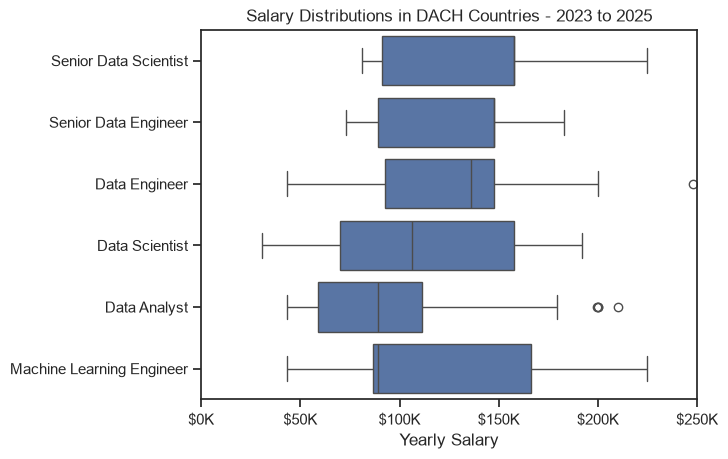

In [24]:
#Create visualization for the salary distribution in the top 6 data jobs in DACH countries

sns.boxplot(data=df_DACH_top6,x="salary_year_avg",y="job_title_short",order=jobs_orderedby_median)
sns.set_theme(style="ticks")

plt.title("Salary Distributions in DACH Countries - 2023 to 2025")
plt.xlabel("Yearly Salary")
plt.ylabel("")
plt.xlim(0,250_000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${int(x/1000)}K"))

plt.show()

##Investigate Median Salary vs Skill Demand for Data Jobs in DACH

In [8]:
#Refer to DACH data frame from previous analysis (nan values for yearly salary excluded)

In [9]:
#Expand/Explode job skills column

df_DACH_expl = df_DACH.explode(column="job_skills").copy()

In [ ]:
#Identify top 10 best paying skills

df_DACH_skillsbymedian = df_DACH_expl.groupby("job_skills")["salary_year_avg"].agg(["count","median"]).sort_values(by="median",ascending=False).head(10)

In [17]:
#Identify top 10 most prominent skills (ordered by median)

df_DACH_skillsbyprom = df_DACH_expl.groupby("job_skills")["salary_year_avg"].agg(["count","median"]).sort_values(by="count",ascending=False).head(10)

df_DACH_skillsbyprom = df_DACH_skillsbyprom.sort_values(by="median",ascending=False)

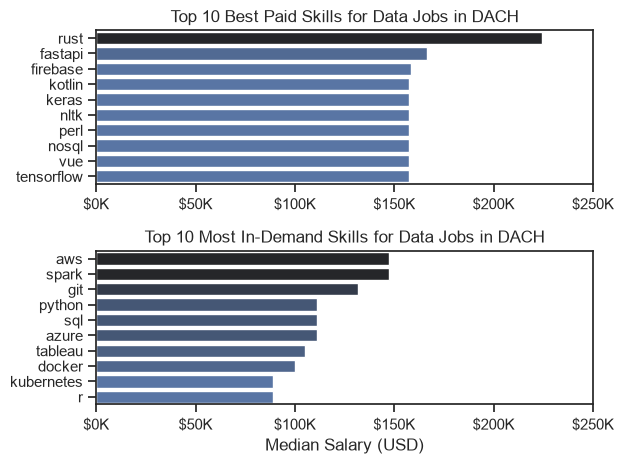

In [22]:
#Visualize top paying vs most prominent skills

#Set up main and sub plots
fig,ax = plt.subplots(2,1)
sns.set_theme(style="ticks")

#Configure top 10 best paying skills visualization
sns.barplot(data=df_DACH_skillsbymedian,x="median",y=df_DACH_skillsbymedian.index,hue="median",ax=ax[0],palette="dark:b_r")
ax[0].legend().remove()
ax[0].set_title("Top 10 Best Paid Skills for Data Jobs in DACH")
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${int(x/1000)}K"))
ax[0].set_xlim(0,250_000)


#Configure top 10 most in-demand skills visualization
sns.barplot(data=df_DACH_skillsbyprom,x="median",y=df_DACH_skillsbyprom.index,hue="median",ax=ax[1],palette="dark:b_r")
ax[1].legend().remove()
ax[1].set_title("Top 10 Most In-Demand Skills for Data Jobs in DACH")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_ylabel("")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${int(x/1000)}K"))
ax[1].set_xlim(0,250_000)


#Clean up main plot layout
fig.tight_layout()
plt.show()